In [32]:
import os
import numpy as np
import matplotlib.pyplot as plt

from deepad.simulation.utils import load_results

In [33]:
data_dir = "../data/results/sim_results2/s_parameters"

#### Sort by length

In [34]:
design_params, freq_response = load_results(data_dir)
sort_inds = np.argsort(design_params[:, 0])
design_params = design_params[sort_inds]
freq_response = freq_response[sort_inds]

In [35]:
length_width = design_params[:, 0] / design_params[:, 1]

#### Resonance mask

In [36]:
resonance_mask = np.any(freq_response[:, :, 1] < -20, axis = 1)

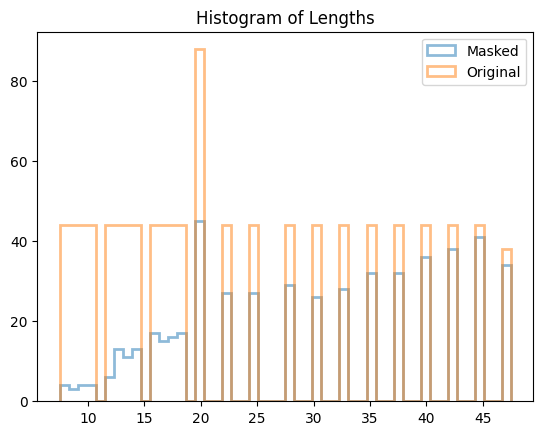

In [21]:
plt.hist(design_params[resonance_mask, 0], label="Masked", bins=50, alpha=0.5, histtype='step', linewidth=2)
plt.hist(design_params[:, 0], label="Original", bins=50, alpha=0.5, histtype='step', linewidth=2)
plt.title("Histogram of Lengths")
plt.legend()

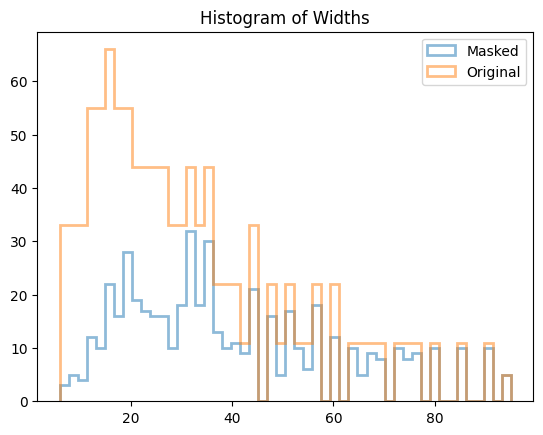

In [22]:
plt.hist(design_params[resonance_mask, 1], label="Masked", bins=50, alpha=0.5, histtype='step', linewidth=2)
plt.hist(design_params[:, 1], label="Original", bins=50, alpha=0.5, histtype='step', linewidth=2)
plt.title("Histogram of Widths")
plt.legend()

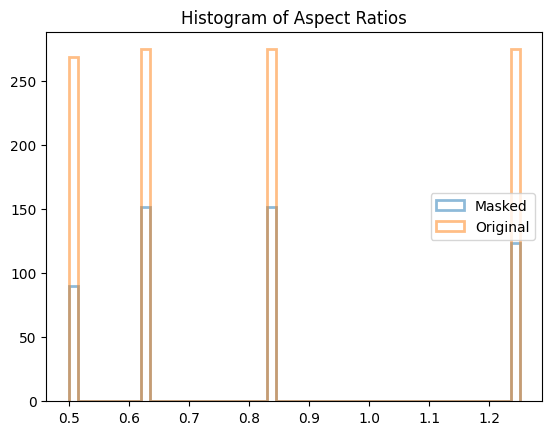

In [23]:
plt.hist(length_width[resonance_mask], label="Masked", bins=50, alpha=0.5, histtype='step', linewidth=2)
plt.hist(length_width, label="Original", bins=50, alpha=0.5, histtype='step', linewidth=2)
plt.title("Histogram of Aspect Ratios")
plt.legend()

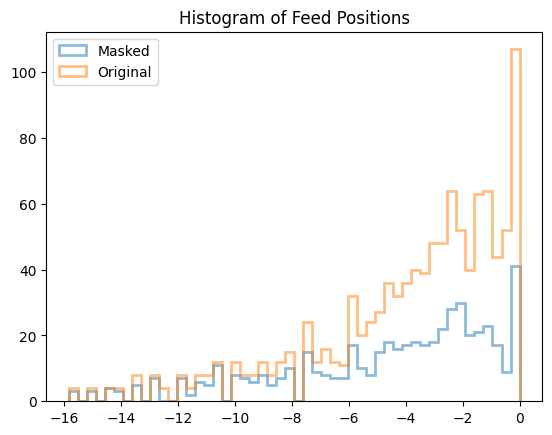

In [24]:
plt.hist(design_params[resonance_mask, 2], label="Masked", bins=50, alpha=0.5, histtype='step', linewidth=2)
plt.hist(design_params[:, 2], label="Original", bins=50, alpha=0.5, histtype='step', linewidth=2)
plt.title("Histogram of Feed Positions")
plt.legend()

#### Filter datapoints with no resonance

In [25]:
design_params_res = design_params[resonance_mask]
freq_response_res = freq_response[resonance_mask]

#### Save data

In [11]:
output_dir = "../data/results/sim_results2/preprocessed"
if not os.path.exists(output_dir):
    os.makedirs(output_dir) 

np.save(os.path.join(output_dir, "design_params.npy"), design_params_res)   
np.save(os.path.join(output_dir, "freq_response.npy"), freq_response_res)

In [37]:
output_dir = "../data/results/sim_results2/preprocessed_all"
if not os.path.exists(output_dir):
    os.makedirs(output_dir) 

np.save(os.path.join(output_dir, "design_params.npy"), design_params)   
np.save(os.path.join(output_dir, "freq_response.npy"), freq_response)

In [12]:
i = 0

[47.5   57.    -7.917]


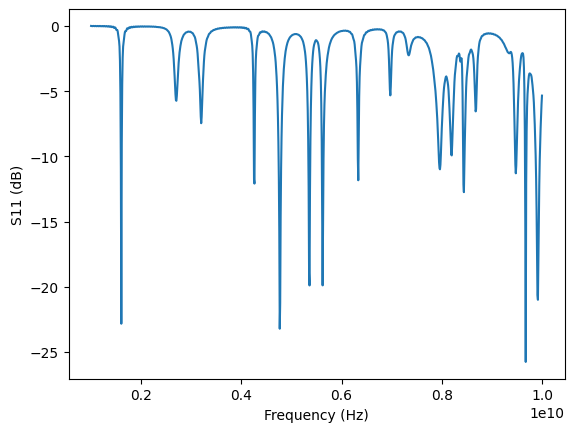

In [26]:
plt.plot(freq_response[i, :, 0], freq_response[i, :, 1])

plt.xlabel("Frequency (Hz)")
plt.ylabel("S11 (dB)")

print(design_params[i])
i -=1

# for file in os.listdir(data_dir):
#     datapoint = np.load(os.path.join(data_dir, file), allow_pickle=True)
#     freqs = datapoint["frequency"]
#     s11 = datapoint["s11"]
#     config = datapoint["config"]

/var/folders/yt/5bbs78k15qd494t52z63npmm0000gn/T/ipykernel_54378/3723273793.py:64: RuntimeWarning: divide by zero encountered in log10
  20*np.log10(denoised_fft[:len(freq_points)//2]),


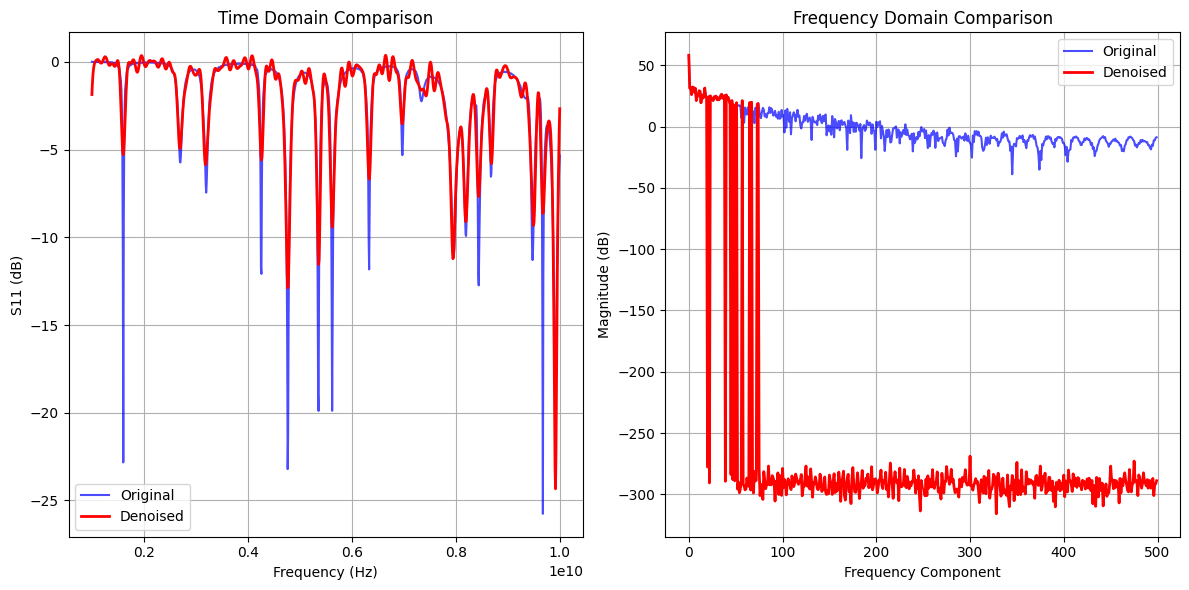

In [29]:
import numpy as np
from scipy.fft import fft, ifft
import matplotlib.pyplot as plt

def denoise_s11(freq, s11, threshold_percentage=5):
    """
    Denoise S11 data using Fourier Transform
    
    Parameters:
    freq: frequency points
    s11: S11 measurements in dB
    threshold_percentage: percentage of FFT coefficients to keep
    
    Returns:
    Denoised S11 data
    """
    # Convert from dB to linear scale for processing
    s11_linear = 10**(s11/20)
    
    # Compute FFT
    fft_result = fft(s11_linear)
    
    # Calculate magnitude spectrum
    magnitude_spectrum = np.abs(fft_result)
    
    # Sort magnitudes to find threshold
    sorted_magnitudes = np.sort(magnitude_spectrum)[::-1]
    n_coefficients = int(len(sorted_magnitudes) * threshold_percentage/100)
    threshold = sorted_magnitudes[n_coefficients]
    
    # Create mask and apply threshold
    mask = magnitude_spectrum > threshold
    filtered_fft = fft_result * mask
    
    # Inverse FFT and convert back to dB
    denoised_linear = np.real(ifft(filtered_fft))
    denoised_db = 20 * np.log10(np.abs(denoised_linear))
    
    return denoised_db

def plot_comparison(freq, original_s11, denoised_s11):
    """Plot original and denoised data"""
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.plot(freq, original_s11, 'b-', label='Original', alpha=0.7)
    plt.plot(freq, denoised_s11, 'r-', label='Denoised', linewidth=2)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('S11 (dB)')
    plt.legend()
    plt.grid(True)
    plt.title('Time Domain Comparison')
    
    # Plot FFT magnitude spectrum
    plt.subplot(1, 2, 2)
    original_fft = np.abs(fft(10**(original_s11/20)))
    denoised_fft = np.abs(fft(10**(denoised_s11/20)))
    freq_points = np.arange(len(freq))
    
    plt.plot(freq_points[:len(freq_points)//2], 
             20*np.log10(original_fft[:len(freq_points)//2]), 
             'b-', label='Original', alpha=0.7)
    plt.plot(freq_points[:len(freq_points)//2], 
             20*np.log10(denoised_fft[:len(freq_points)//2]), 
             'r-', label='Denoised', linewidth=2)
    plt.xlabel('Frequency Component')
    plt.ylabel('Magnitude (dB)')
    plt.legend()
    plt.grid(True)
    plt.title('Frequency Domain Comparison')
    
    plt.tight_layout()
    plt.show()

# Example usage (assuming data is loaded into freq and s11):
denoised_data = denoise_s11(freq_response[i+1, :, 0], freq_response[i+1, :, 1] , threshold_percentage=10)
plot_comparison(freq_response[i+1, :, 0], freq_response[i+1, :, 1], denoised_data)

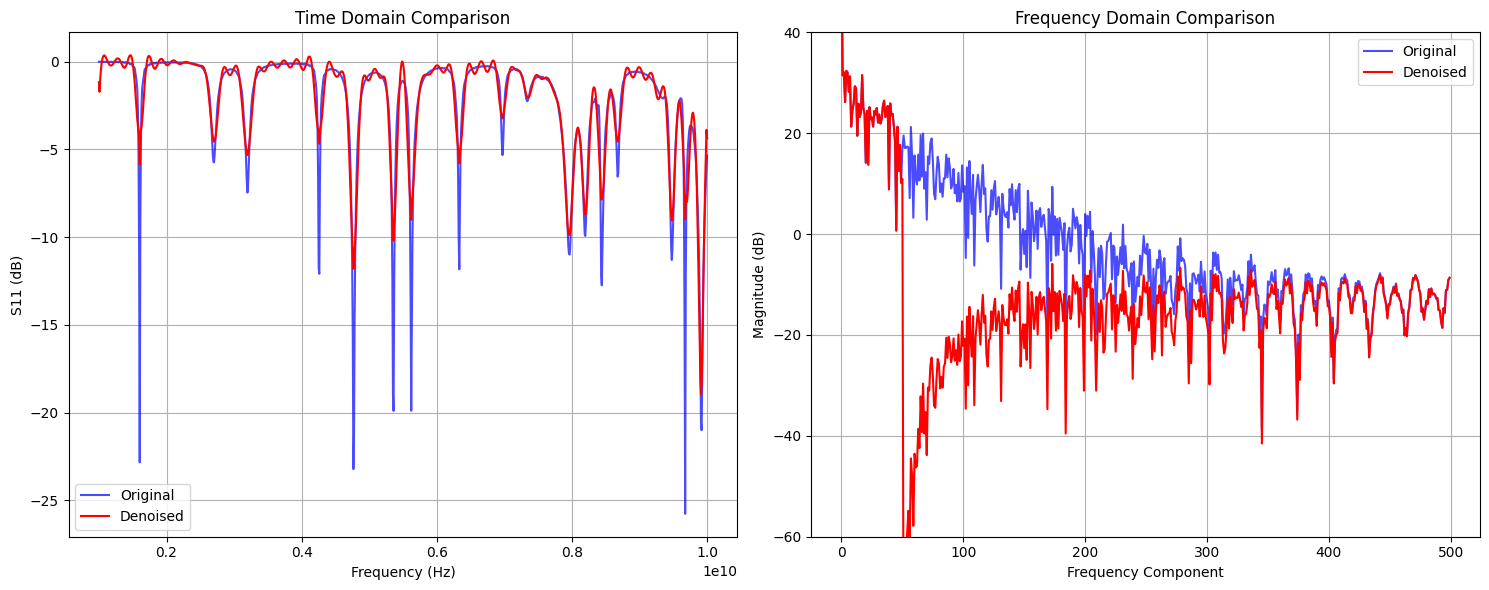

In [31]:
import numpy as np
from scipy.fft import fft, ifft
import matplotlib.pyplot as plt

def denoise_s11_improved(freq, s11, window_size=0.05, min_threshold_db=-40):
    """
    Improved S11 denoising that better preserves resonance features
    
    Parameters:
    freq: frequency points
    s11: S11 measurements in dB
    window_size: fraction of FFT coefficients to use for smoothing
    min_threshold_db: minimum threshold for FFT components
    """
    # Convert from dB to linear scale
    s11_linear = 10**(s11/20)
    
    # Compute FFT
    fft_result = fft(s11_linear)
    n_points = len(fft_result)
    
    # Create a smoothing window that preserves low-frequency components
    window = np.ones(n_points)
    cutoff = int(n_points * window_size)
    window[cutoff:-cutoff] = np.hanning(n_points - 2*cutoff)
    
    # Apply window and threshold
    magnitude = np.abs(fft_result)
    phase = np.angle(fft_result)
    
    # Threshold in dB domain to preserve small but important components
    magnitude_db = 20 * np.log10(magnitude + 1e-10)
    magnitude_db = np.maximum(magnitude_db, min_threshold_db)
    magnitude = 10**(magnitude_db/20)
    
    # Reconstruct signal
    filtered_fft = magnitude * np.exp(1j * phase) * window
    
    # Inverse FFT and convert back to dB
    denoised_linear = np.real(ifft(filtered_fft))
    denoised_db = 20 * np.log10(np.abs(denoised_linear))
    
    return denoised_db

def plot_improved_comparison(freq, original_s11, denoised_s11):
    """Plot original and denoised data with improved visualization"""
    plt.figure(figsize=(15, 6))
    
    # Time domain comparison
    plt.subplot(1, 2, 1)
    plt.plot(freq, original_s11, 'b-', label='Original', linewidth=1.5, alpha=0.7)
    plt.plot(freq, denoised_s11, 'r-', label='Denoised', linewidth=1.5)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('S11 (dB)')
    plt.legend()
    plt.grid(True)
    plt.title('Time Domain Comparison')
    
    # Frequency domain comparison
    plt.subplot(1, 2, 2)
    original_fft = np.abs(fft(10**(original_s11/20)))
    denoised_fft = np.abs(fft(10**(denoised_s11/20)))
    freq_points = np.arange(len(freq))[:len(freq)//2]
    
    # Plot only up to Nyquist frequency and limit dB range
    plt.plot(freq_points, 
             20*np.log10(original_fft[:len(freq_points)]), 
             'b-', label='Original', alpha=0.7)
    plt.plot(freq_points, 
             20*np.log10(denoised_fft[:len(freq_points)]), 
             'r-', label='Denoised')
    plt.xlabel('Frequency Component')
    plt.ylabel('Magnitude (dB)')
    plt.ylim(-60, 40)  # Limit vertical range to meaningful values
    plt.legend()
    plt.grid(True)
    plt.title('Frequency Domain Comparison')
    
    plt.tight_layout()
    plt.show()

# Example usage:
# denoised_data = denoise_s11_improved(freq, s11, window_size=0.05)
# plot_improved_comparison(freq, s11, denoised_data)

denoised_data = denoise_s11_improved(freq_response[i+1, :, 0], freq_response[i+1, :, 1])
plot_improved_comparison(freq_response[i+1, :, 0], freq_response[i+1, :, 1], denoised_data)

[ 7.5  15.   -1.75]


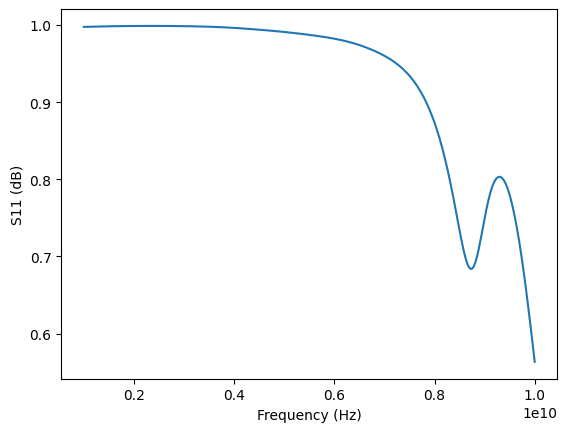

In [96]:
linear_scale = 10 ** (freq_response[i, :, 1] / 20)
plt.plot(freq_response[i, :, 0], linear_scale)
plt.xlabel("Frequency (Hz)")
plt.ylabel("S11 (dB)")
print(design_params[i])
i +=1

In [272]:
from scipy.signal import resample

In [274]:
new_s11, new_t = resample(freq_response[i, :, 1], 500, t = freq_response[i, :, 0])

[35.    56.    -5.833]


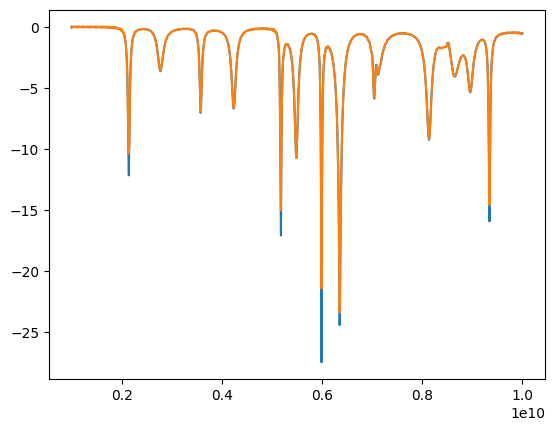

In [275]:
plt.plot(freq_response[i, :, 0], freq_response[i, :, 1])
plt.plot(new_t, new_s11)
print(design_params[i])
# i =1